## ARIMA Baseline Forecasting

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ARIMA modeli
from statsmodels.tsa.arima.model import ARIMA


In [35]:
df = pd.read_csv("../data/processed/langchain_global_clean.csv")

df.head()

,date,trend_score,isPartial
0,2023-08-06,25,False
1,2023-08-13,23,False
2,2023-08-20,25,False
3,2023-08-27,21,False
4,2023-09-03,22,False


In [36]:
## Veri setinin sütunlarını ve boyutunu kontrol ediyoruz.

print(df.columns)
print(df.shape)

df.tail()

Index(['date', 'trend_score', 'isPartial'], dtype='str')
(158, 3)


,date,trend_score,isPartial
153,2026-07-12,44,False
154,2026-07-19,50,False
155,2026-07-26,42,False
156,2026-08-02,30,False
157,2026-08-09,25,False


In [37]:
if "isPartial" in df.columns:

    df = df[df["isPartial"] == False].copy()

    df = df.drop(columns=["isPartial"])

df["date"] = pd.to_datetime(df["date"])


## Zaman serisini eski tarihten yeni tarihe doğru sıralıyoruz.

df = (df.sort_values("date").reset_index(drop=True))

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         158 non-null    datetime64[us]
 1   trend_score  158 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 2.6 KB


In [39]:
df.tail()

,date,trend_score
153,2026-07-12,44
154,2026-07-19,50
155,2026-07-26,42
156,2026-08-02,30
157,2026-08-09,25


In [40]:
## Verimiz haftalık olduğu için son 4 gözlemi test olarak ayırıyoruz.
## 4 hafta yaklaşık 28 gün olduğu için projenin
## 30 günlük tahmin hedefine yakın bir değerlendirme yapıyoruz.
##
## Zaman serisi olduğu için shuffle kullanmıyoruz.

forecast_steps = 4

train_df = df.iloc[:-forecast_steps].copy()

test_df = df.iloc[-forecast_steps:].copy()

## forecast_steps --> test setinde kaç gözlem olacağını belirliyor.

In [41]:
print("Train başlangıç:",train_df["date"].min())

print("Train bitiş:",train_df["date"].max())

print("Test başlangıç:",test_df["date"].min())

print("Test bitiş:",test_df["date"].max())

Train başlangıç: 2023-08-06 00:00:00
Train bitiş: 2026-07-12 00:00:00
Test başlangıç: 2026-07-19 00:00:00
Test bitiş: 2026-08-09 00:00:00


In [42]:
## ARIMA için yalnızca hedef zaman serisini oluşturuyoruz.

train_series = train_df.set_index("date")["trend_score"]
test_series = test_df.set_index("date")["trend_score"]

In [43]:
train_series.head()

date
2023-08-06    25
2023-08-13    23
2023-08-20    25
2023-08-27    21
2023-09-03    22
Name: trend_score, dtype: int64

##### ARIMA(p, d, q)
##### p → geçmiş değerlerin etkisi
#####     AutoRegressive

##### d → kaç kez fark aldığımız
 #####    Integrated

##### q → geçmiş tahmin hatalarının etkisi
 #####    Moving Average

#### ADF Testi ---> ADF testini sadece TRAIN üzerinde yapıyoruz

#### ADF testi --> d --> Zaman serisinin durağan olup olmadığını test etmek için kullanılan bir istatistiksel testtir.

In [44]:
# Zaman serisinin durağanlığını test etmek için Augmented Dickey-Fuller testi
from statsmodels.tsa.stattools import adfuller

In [45]:
## Augmented Dickey-Fuller testini
## yalnızca eğitim verisi üzerinde uyguluyoruz.

adf_result = adfuller(train_series)

In [46]:
## ADF testinin temel sonuçlarını yazdırıyoruz.

print("ADF Statistic:",adf_result[0])

print("p-value:",adf_result[1])

ADF Statistic: -2.0900379936323508
p-value: 0.2485391963644547


#####  H0: Seride unit root vardır. Yani seri durağan değildir.

##### p-value < 0.05 -> H0 reddedilir -> Durağanlık lehine kanıt var

##### p-value > 0.05 -> H0 reddedilemez -> Durağanlık lehine kanıt yok

In [47]:
## Serinin birinci farkını alıyoruz
## Mevcut haftanın trend_score değerinden bir önceki haftanın trend_score değerini çıkarıyoruz.
## Amaç trend etkisini azaltıp ve seriyi durağan hale getirmektir.

train_diff = train_series.diff().dropna()

## diff() fonksiyonu ile birinci farkı alıyoruz ve dropna() ile NaN değerleri kaldırıyoruz.

In [48]:
## Yeni ADF testi

adf_diff_result = adfuller(train_diff)

print("ADF Statistic:", adf_diff_result[0])
print("p-value:", adf_diff_result[1])

ADF Statistic: -10.199979354668232
p-value: 6.005877536887892e-18




##### Yeni p-value değeri 0.05'ten oldukça küçük olduğu için H0 reddedildi
##### Bu sonuç, birinci fark sonrası serinin durağan hale geldiğini gösteriyor. Bu nedenle, ARIMA modelimiz için d=1 olarak belirlenebilir.

##### eğer p-value değeri 0.05'ten büyük olsaydı, serinin durağan olmadığı sonucuna varırdık ve d=1 olarak belirleyemezdik. Bunun için diff() fonksiyonunu bir kez daha uygulayarak ikinci farkı alırdık ve tekrar ADF testini uygular ve p-value değerine bakardık. Eğer ikinci fark sonrası p-value değeri 0.05'ten küçük olursa, serinin durağan hale geldiğini ve d=2 olarak belirlenebileceğini söyleyebilirdik. Ama gereksiz yere ikinci farkı almak, modelin karmaşıklığını artırır ve overfitting riskini yükseltir. Bu nedenle, mümkün olduğunca düşük d değeri tercih edilir.

#### ARIMA (p,1,q)

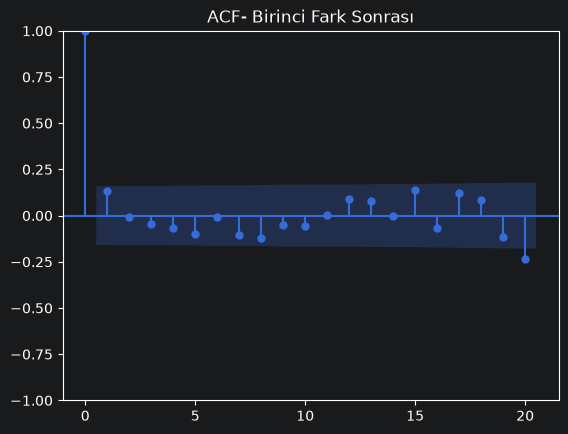

In [49]:
#ACF ve PACF grafikleri için
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## ACF özellikle q(Moving Avarage) parametresi
## için başlangıç değeri belirlememize yardımcı olur.

plot_acf(train_diff, lags=20)
##lags --> kaç gecikme (lag) için ACF ve PACF grafiğini çizmek istediğimizi belirtiyor. 20 gecikme için çiziyoruz.

plt.title("ACF- Birinci Fark Sonrası")
plt.show()

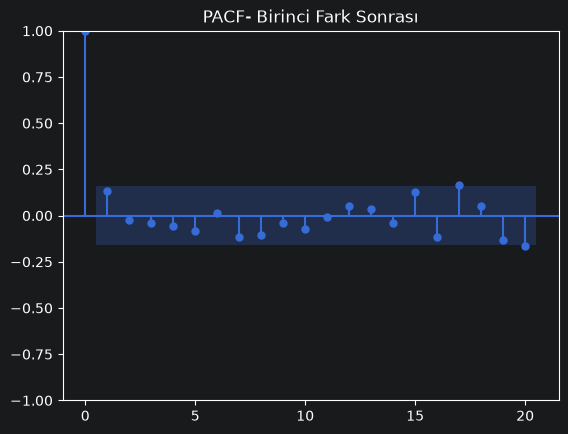

In [50]:
## PACF grafiğini çiziyoruz.
##
## PACF özellikle p (AutoRegressive) parametresi
## için başlangıç değeri belirlememize yardımcı olur.

plot_pacf(train_diff, lags=20)

plt.title("PACF- Birinci Fark Sonrası")
plt.show()

In [51]:
## ARIMA modellerinin sonuçlarını saklamak için
## boş bir liste oluşturuyoruz.

arima_results = []


## ACF ve PACF grafiklerinde güçlü yüksek dereceli bir yapı
## görülmediği için p ve q değerlerini 0, 1 ve 2 olarak deniyoruz.

for p in range(3):

    for q in range(3):

        ## d değerini ADF testi sonucunda 1 olarak belirlemiştik.

        order = (p, 1, q)

        try:

            ## Modeli ORİJİNAL train serisi üzerinde kuruyoruz.
            ##
            ## train_diff kullanmıyoruz çünkü order içindeki d=1,
            ## differencing işlemini modelin kendisinin yapmasını sağlar.

            model = ARIMA(
                train_series,
                order=order
            )


            ## Model parametrelerini eğitim verisine göre tahmin ediyoruz.

            fitted_model = model.fit()


            ## Her aday modelin AIC ve BIC değerlerini saklıyoruz.

            arima_results.append(
                {
                    "order": order,
                    "AIC": fitted_model.aic,
                    "BIC": fitted_model.bic
                }
            )


        except Exception as error:

            ## Bazı model kombinasyonları sayısal nedenlerle
            ## kurulamayabilir. Böyle bir durumda programı durdurmak
            ## yerine hangi modelde hata olduğunu gösteriyoruz.

            print(
                f"ARIMA{order} kurulamadı:",
                error
            )

C:\Users\sanug\Documents\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\sanug\Documents\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\sanug\Documents\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\sanug\Documents\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\sanug\Documents\trend_forecasting\.venv\Lib\site-packages\s

In [52]:
## Liste içerisinde tuttuğumuz model sonuçlarını
## DataFrame'e dönüştürüyoruz.

arima_selection_df = pd.DataFrame(
    arima_results
)


## AIC değerine göre küçükten büyüğe sıralıyoruz.

arima_selection_df = (
    arima_selection_df
    .sort_values("AIC")
    .reset_index(drop=True)
)


arima_selection_df

,order,AIC,BIC
0,"(2, 1, 2)",982.161226,997.313416
1,"(0, 1, 1)",988.006852,994.067728
2,"(1, 1, 0)",988.041691,994.102566
3,"(2, 1, 1)",988.283927,1000.405679
4,"(0, 1, 0)",989.043543,992.073981
5,"(2, 1, 0)",989.978914,999.070227
6,"(0, 1, 2)",989.995608,999.086922
7,"(1, 1, 1)",989.998813,999.090126
8,"(1, 1, 2)",991.826167,1003.947918


#### ARIMA Model Seçimi

ACF ve PACF grafiklerinde güçlü yüksek dereceli bir AR veya MA yapısı
görülmediğinden küçük p ve q değerleri denendi.

Aday modeller AIC ve BIC bilgi kriterleri kullanılarak karşılaştırıldı.

En düşük AIC değeri ARIMA(2,1,2) modelinde elde edildi (977.13). Ancak bu model
gerçek test/CV performansında ARIMA(0,1,1)'e göre daha kötü sonuç verdi
(daha yüksek MAE). Bunun sebebi, AIC'nin train verisine uyumu ölçmesi ve
daha fazla parametreli (p=2, q=2) modellerin train verisindeki gürültüyü de
öğrenerek gelecekte daha kötü genelleyebilmesidir (overfitting riski).

BIC zaten daha basit olan ARIMA(0,1,0) modelini tercih ediyordu, bu da
düşük dereceli modellerin yeterli olabileceğine işaret ediyordu.

Bu nedenle baseline model olarak, AIC sıralamasında en düşük değere sahip
model yerine, hem AIC/BIC açısından makul hem de gerçek tahmin performansında
(CV MAE/RMSE) daha tutarlı sonuç veren ARIMA(0,1,1) seçildi.


In [53]:
## AIC değerine göre en iyi aday olan
## ARIMA(2,1,2) modelini train serisi üzerinde kuruyoruz.

selected_order = (0, 1, 1)

arima_model = ARIMA(
    train_series,
    order=selected_order
)

arima_fitted = arima_model.fit()

C:\Users\sanug\Documents\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\sanug\Documents\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\sanug\Documents\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


In [54]:
# Eğitilmiş ARIMA modelinin
## istatistiksel özetini inceliyoruz.

print(arima_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:            trend_score   No. Observations:                  154
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -492.003
Date:                Wed, 19 Aug 2026   AIC                            988.007
Time:                        12:59:02   BIC                            994.068
Sample:                    08-06-2023   HQIC                           990.469
                         - 07-12-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1444      0.050      2.878      0.004       0.046       0.243
sigma2        36.3578      2.064     17.618      0.000      32.313      40.403
Ljung-Box (L1) (Q):                   0.00   Jarque-

In [55]:
## Test setinde kaç gözlem varsa
## o kadar ileri dönem tahmini üretiyoruz.

arima_test_forecast = arima_fitted.forecast(
    steps=len(test_series)
)

In [56]:
len(test_series)

4

In [57]:
## Tahminlerin tarih indexini
## gerçek test tarihleriyle eşleştiriyoruz.

arima_test_forecast.index = test_series.index

In [58]:
## Gerçek test değerlerini ve ARIMA tahminlerini
## aynı DataFrame içerisinde topluyoruz.

arima_results_df = pd.DataFrame(
    {
        "actual": test_series,
        "predicted": arima_test_forecast
    }
)


arima_results_df.head()

,actual,predicted
date,,
2026-07-19,50,41.346941
2026-07-26,42,41.346941
2026-08-02,30,41.346941
2026-08-09,25,41.346941


#### Tek Test Döneminde Hata Metrikleri


In [59]:
# Tahmin hatalarını ölçmek için sklearn'den MAE ve RMSE fonksiyonlarını çağırıyoruz.
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Ortalama mutlak hata (MAE): tahminlerin gerçek değerden ortalama ne kadar saptığını gösterir.
arima_mae = mean_absolute_error(
    arima_results_df["actual"],
    arima_results_df["predicted"]
)

# RMSE: büyük hataları normal hatalardan daha fazla cezalandıran bir metrik.
arima_rmse = root_mean_squared_error(
    arima_results_df["actual"],
    arima_results_df["predicted"]
)

print(f"ARIMA MAE : {arima_mae:.2f}")
print(f"ARIMA RMSE: {arima_rmse:.2f}")


ARIMA MAE : 9.25
ARIMA RMSE: 10.85


In [60]:
# Cross-validation için tüm veri setini (train+test ayrımı yapmadan) tek bir seri haline getiriyoruz.
full_series = df.set_index("date")["trend_score"]


#### Zaman Serisine Uygun Basit Cross-Validation

Yukarıdaki MAE/RMSE tek bir test döneminden (son 4 hafta) geliyor. Bu sonucun şansa mı bağlı olduğunu, yoksa modelin genel olarak mı böyle davrandığını anlamak için aynı modeli **3 farklı zaman noktasında** ayrı ayrı test ediyoruz.

Mantık: veriyi belirli bir noktadan (cutoff) kesiyoruz, o noktaya kadar olan kısımla model eğitip sonraki 4 haftayı tahmin ediyoruz. Bunu 3 farklı cutoff için tekrarlıyoruz.

(Prophet'te bunun için hazır `cross_validation()` fonksiyonunu kullanmıştık; statsmodels'de böyle hazır bir fonksiyon olmadığı için burada manuel/basit bir şekilde yapıyoruz.)


In [61]:
# ARIMA modelini test edeceğimiz 3 farklı cutoff noktası.
# Her sayı, veri setindeki kaçıncı haftaya kadar (index) eğitim yapılacağını gösterir.
# Aralarında yaklaşık 30'ar haftalık (~7 ay) mesafe bırakarak veriyi genele yaydık.
cutoffs = [100, 130, 154]

# Her cutoff için hesaplanan MAE/RMSE değerlerini bu listede topluyoruz.
cv_results_list = []

for cutoff in cutoffs:

    # Bu cutoff noktasına kadar olan veri = eğitim seti
    train_part = full_series.iloc[:cutoff]

    # Cutoff'tan sonraki 4 hafta = test seti
    test_part = full_series.iloc[cutoff: cutoff + 4]

    # Modeli bu eğitim seti ile kuruyoruz (order daha önce seçtiğimiz (0,1,1))
    model = ARIMA(train_part, order=selected_order)
    fitted = model.fit()

    # Sonraki 4 haftayı tahmin ediyoruz
    forecast = fitted.forecast(steps=4)
    forecast.index = test_part.index

    # Bu cutoff için MAE ve RMSE hesaplıyoruz
    mae = mean_absolute_error(test_part, forecast)
    rmse = root_mean_squared_error(test_part, forecast)

    cv_results_list.append({
        "cutoff_date": train_part.index[-1],
        "mae": mae,
        "rmse": rmse
    })

    print(f"Cutoff: {train_part.index[-1].date()} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")


Cutoff: 2025-06-29 | MAE: 4.08 | RMSE: 7.12
Cutoff: 2026-01-25 | MAE: 14.50 | RMSE: 18.92
Cutoff: 2026-07-12 | MAE: 9.25 | RMSE: 10.85


C:\Users\sanug\Documents\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\sanug\Documents\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\sanug\Documents\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\sanug\Documents\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\sanug\Documents\trend_forecasting\.venv\Lib\site-packages\s

In [62]:
# 3 cutoff noktasının sonuçlarını tablo halinde görelim
cv_results_df = pd.DataFrame(cv_results_list)
cv_results_df


,cutoff_date,mae,rmse
0,2025-06-29,4.079163,7.115711
1,2026-01-25,14.500000,18.915757
2,2026-07-12,9.250000,10.854463


In [63]:
# 3 farklı dönemin ortalama MAE ve RMSE değeri
# Bu sayı, tek test dönemindeki (arima_mae, arima_rmse) sonuçla karşılaştırılmalı.
# İkisi birbirine yakınsa model tutarlı demektir; çok farklıysa tek test döneminin
# şansa bağlı (ya da o dönemin özel bir davranışı) olduğu anlaşılır.
arima_cv_mae = cv_results_df["mae"].mean()
arima_cv_rmse = cv_results_df["rmse"].mean()

print(f"ARIMA CV Ortalama MAE : {arima_cv_mae:.2f}")
print(f"ARIMA CV Ortalama RMSE: {arima_cv_rmse:.2f}")


ARIMA CV Ortalama MAE : 9.28
ARIMA CV Ortalama RMSE: 12.30


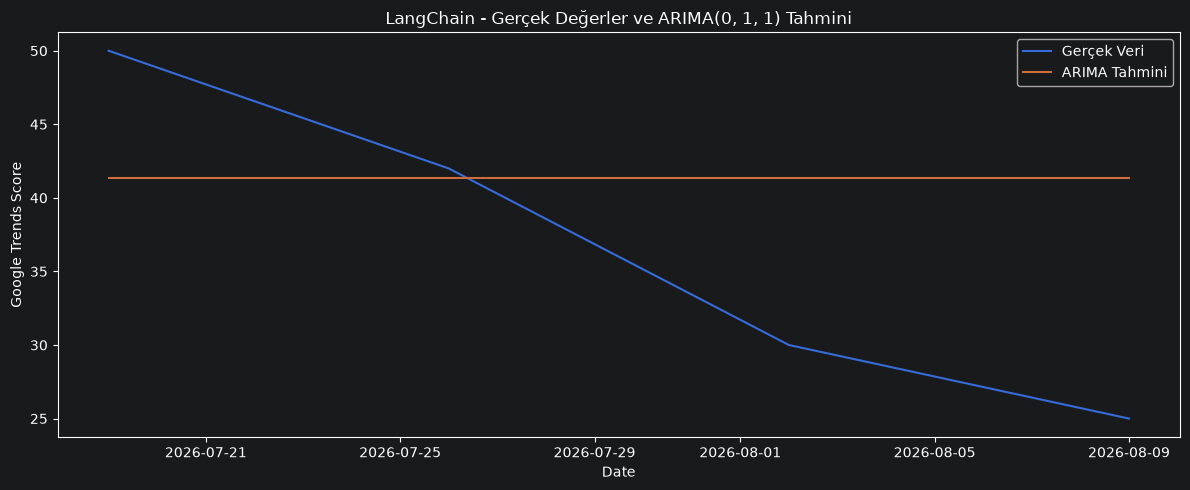

In [64]:
## Test dönemindeki gerçek değerler ile
## ARIMA tahminlerini aynı grafik üzerinde gösteriyoruz.

plt.figure(figsize=(12, 5))


## Gerçek test değerleri

plt.plot(
    arima_results_df.index,
    arima_results_df["actual"],
    label="Gerçek Veri"
)


## ARIMA modelinin tahminleri

plt.plot(
    arima_results_df.index,
    arima_results_df["predicted"],
    label="ARIMA Tahmini"
)


plt.title(
    f"LangChain - Gerçek Değerler ve ARIMA{selected_order} Tahmini"
)

plt.xlabel("Date")
plt.ylabel("Google Trends Score")

plt.legend()

plt.tight_layout()
plt.show()

In [65]:
## Gerçek değerler ile tahminleri yan yana inceliyoruz.

arima_results_df.head(10)

,actual,predicted
date,,
2026-07-19,50,41.346941
2026-07-26,42,41.346941
2026-08-02,30,41.346941
2026-08-09,25,41.346941
